# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [45]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
# importar librerías

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')  #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [6]:
plans.head(5) # mosusertrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
users.isna().sum() # cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
usage.isna().sum()
print(usage.isna().sum()) 
print(usage.isna().mean()) # cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  duration y length en USAGE tienen 55 y 44 porciento en nulos lo que indica al rededor de la mitad de nulos en ambas columnas lo cual es idoneo ya que esta dos secciones dependen la una de la otra por un lado tenemos llamas que se evaluan por tiempo y en longth no aplicaria ya que esta solo mide la cantidad en texto basicamente no hay nada malo con ambas.
  Observando USERS churn date con 88% and city 11% pasa lo mismo consultamos quién puede tener información para completar city de lo contrario buscaría el promedio de las ciudades más mencionadas e imputaría, en churn no haría nada ya que este dato está más relacionado a quienes dejar el servicio y por ende si muchos no lo han dejado saldrá como nulo  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
users[['age', 'user_id']].describe() # explorar columnas numéricas de users

,age,user_id
count,4000.000000,4000.000000
mean,33.739750,11999.500000
std,123.232257,1154.844867
min,-999.000000,10000.000000
25%,32.000000,10999.750000
50%,47.000000,11999.500000
75%,63.000000,12999.250000
max,79.000000,13999.000000


- La columna `user_id` tiene 4 mil valores empezando desde 10 k hasta 13.999 k no se ve nada anomalo
- La columna `age` cuenta con outliers vemos que tiene como minima un valor inválido para edad.

In [16]:
usage[['id', 'user_id', 'length', 'duration']].describe() # explorar columnas numéricas de usage

,id,user_id,length,duration
count,40000.00000,40000.000000,22104.000000,17924.000000
mean,20000.50000,12002.405975,52.127398,5.202237
std,11547.14972,1157.279564,56.611183,6.842701
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,37.000000,1.437500
50%,20000.50000,12013.000000,50.000000,3.500000
75%,30000.25000,13005.000000,64.000000,6.990000
max,40000.00000,13999.000000,1490.000000,120.000000


In [17]:

users[['city', 'plan']].value_counts() # explorar columnas categóricas de users




city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` muestra ciudades de colombia y nos muestra un ? que debe significar que se desconoce la ciudad o simplemente es un dato invalido, ademas se repiten algunas ciudades dependiendo del plan que hayan elegido 
- La columna `plan` solo vemos dos tipos de plan basico y premium 


In [18]:
# explorar columna categórica de usage
usage[['type']].value_counts()  # completa el código

type
text    22092
call    17908
dtype: int64

- En la columna `type` solo manejamos dos tipos de servicios, por decirlo así: texto y llamadas; entre ambos suman 40000, que es el total de datos tipeados en nuestro data.


---

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  city con valores con ? y en AGE que cuenta con valores negativos como se evidencia en valor minimo
- ¿Qué acción tomarías?,
   para city solo se puede hablar con el equipo encargado de la entrada de datos para ver si tiene mas de estos datos y poder imputar de otro modo solo cambiar (?) y los espacios vacios por NA, en AGE eliminamos todos los valores negativos y podemos imputar con la mediana o avarage de estas mismas ya que no tenemos un sesgo en nuestra columna.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [21]:
users[['reg_date']].value_counts() # Revisar los años presentes en `reg_date` de users


reg_date                     
2026-05-10 00:00:00.000000000    40
2024-01-01 06:34:17.914478624     1
2024-01-01 19:42:53.743435864     1
2024-01-02 02:17:11.657914480     1
2024-01-02 08:51:29.572393104     1
                                 ..
2023-01-04 00:17:17.059264816     1
2023-01-04 06:51:34.973743436     1
2023-01-04 13:25:52.888222056     1
2023-01-04 20:00:10.802700676     1
2023-07-04 13:17:14.358589648     1
Length: 3961, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
2026 con 40 registros sin una hora asignada para cadaz uno de estos registros 

In [22]:
usage[['date']].value_counts() # Revisar los años presentes en `date` de usage


date                         
2024-01-01 00:00:00.000000000    1
2024-04-30 16:32:34.848871220    1
2024-04-30 15:46:58.060451510    1
2024-04-30 15:53:29.030225754    1
2024-04-30 16:00:00.000000000    1
                                ..
2024-03-01 07:46:58.060451511    1
2024-03-01 07:53:29.030225755    1
2024-03-01 08:00:00.000000000    1
2024-03-01 08:06:30.969774244    1
2024-06-30 00:00:00.000000000    1
Length: 39950, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
veo 2 fechas que no fueron completadas con la informacion requerida 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?(años muy viejos o sin transcurrir al momento de guardar los datos)
  para el data users aparece uno que no ha pasado para esto como son tan solo 40 registros yo los eliminaria y los dejaria documentados.
  en cuanto a date solo vemos que no introdujeron los datos en algunas columnas y besto nos muestra nuetsra fecha en 0, podria imputarse con el avarage si esta columna no va a tener un gran impacto en nuestro analisis 
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median() 
users['age'] = users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users[['city']].value_counts() 

city    
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
dtype: int64

In [25]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT
# Verificar cambios
users[['reg_date']].value_counts()

reg_date                     
2022-01-01 00:00:00.000000000    1
2024-01-01 00:00:00.000000000    1
2024-01-01 13:08:35.828957240    1
2024-01-01 19:42:53.743435864    1
2024-01-02 02:17:11.657914480    1
                                ..
2023-01-03 17:42:59.144786200    1
2023-01-04 00:17:17.059264816    1
2023-01-04 06:51:34.973743436    1
2023-01-04 13:25:52.888222056    1
2024-12-31 00:00:00.000000000    1
Length: 3960, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
# Verificación MAR en usage (Missing At Random) para duration
usage[['duration']].isna().groupby(usage['type']).mean().sort_values(by = 'duration', ascending=False)

,duration
type,
text,0.999276
call,0.000000


In [27]:
# Verificación MAR en usage (Missing At Random) para length
usage[['length']].isna().groupby(usage['type']).mean().sort_values(by = 'length', ascending=False)

,length
type,
call,0.99933
text,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
el diagnostico al que llegue analizando fue que los nulos de length y duration son MAR debido a que dependen de type, si tengo texto mido mis textos y si tengo calls mido la duracion de estas lo que hace que estas dos dependan de una sola variable que seria el type.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes'})
usage_agg = usage_agg.rename(columns={'is_call': 'cant_llamadas'})
usage_agg = usage_agg.rename(columns={'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on='user_id', how='left')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [34]:
# Resumen estadístico de las columnas numéricas
usage_agg.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054
std,1154.898108,2.358416,2.144238,18.168095
min,10000.000000,0.000000,0.000000,0.000000
25%,10999.500000,4.000000,3.000000,11.120000
50%,12000.000000,5.000000,4.000000,19.780000
75%,12999.500000,7.000000,6.000000,31.415000
max,13999.000000,17.000000,15.000000,155.690000


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` esta tabla esta mal nombrada anteriormente las instrucciones determinaron el nombre de esta columna como 'can_minutos_llamada'. 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas
  

In [40]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

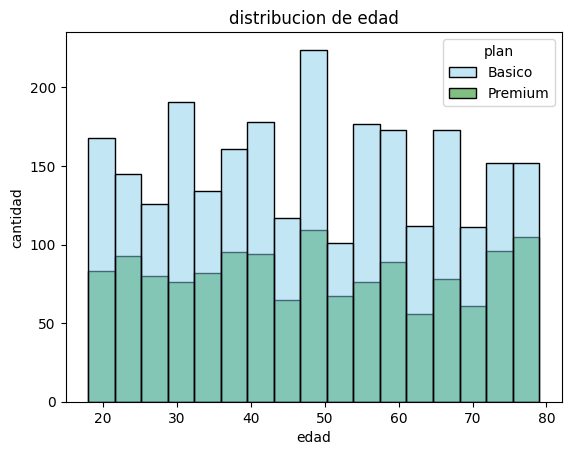

In [47]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('distribucion de edad')
plt.xlabel('edad')
plt.ylabel('cantidad')
plt.show()

💡Insights: 
- Distribución simetrica en donde vemos que al rededor de los clientes con edad de 50 anos es donde mas se concentran tanto nuestros clientes premium como lo de plan basicos, adicional a esto hay muchisima mas poblacion que adquirio el plan basico 

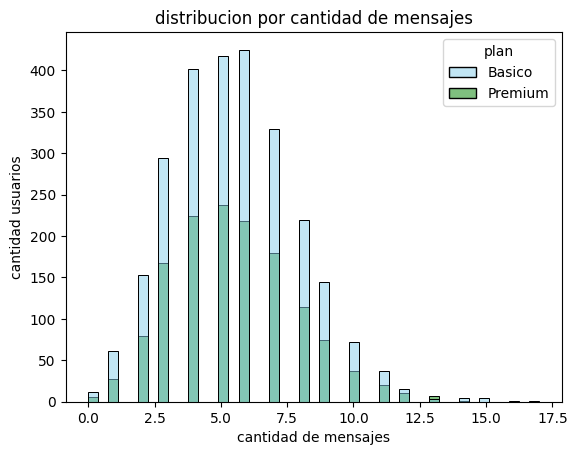

In [51]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('distribucion por cantidad de mensajes')
plt.xlabel('cantidad de mensajes')
plt.ylabel ('cantidad usuarios')
plt.show()


💡Insights: 
- encontramos una distribucion sesgada a la derecha lo que nos indica posibles outliers o simplemente clientes con alto uso de estos mensajes, se logra distinguir en el histograma que los clientes con plana basico utilizan muchos mas mensajes en comparacion con los que tienen paquete premium 

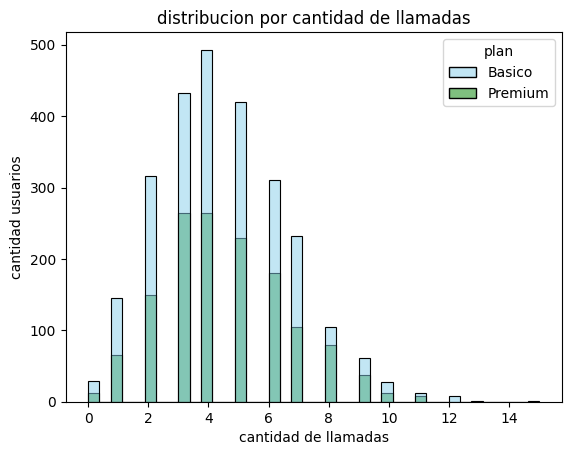

In [52]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('distribucion por cantidad de llamadas')
plt.xlabel('cantidad de llamadas')
plt.ylabel ('cantidad usuarios')
plt.show()

💡Insights: 
- Distribución con sesgo a la derecha que indica outliers que pueden ser clientes que trabajan con sis móviles y requieren gran cantidad de llamadas y vemos que se mantiene el patrón en donde los clientes con planes básico ejecutan más llamadas que nuestros clientes con plan premium 

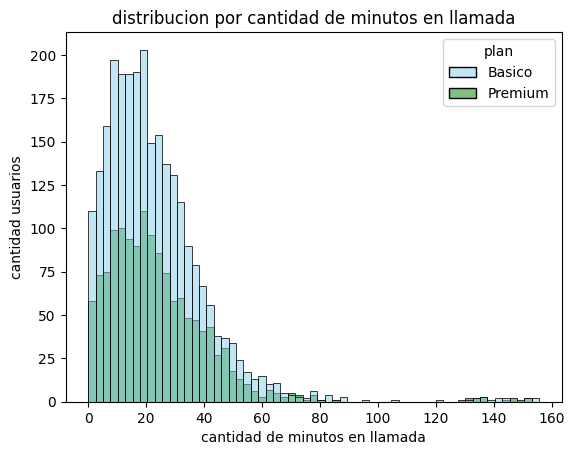

In [53]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('distribucion por cantidad de minutos en llamada')
plt.xlabel('cantidad de minutos en llamada')
plt.ylabel ('cantidad usuarios')
plt.show()

💡Insights: 
- la distribucion tiene un sesgo a la derecha donde mayoritariamente los que mas tienen tiempo en llamda acumulados son clientes con paquete basico lo que nos hace entender que no solo ejecutan mas llamadas si no que tambien gastan mucho mas tiempo en esta e inclusive con mensajes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

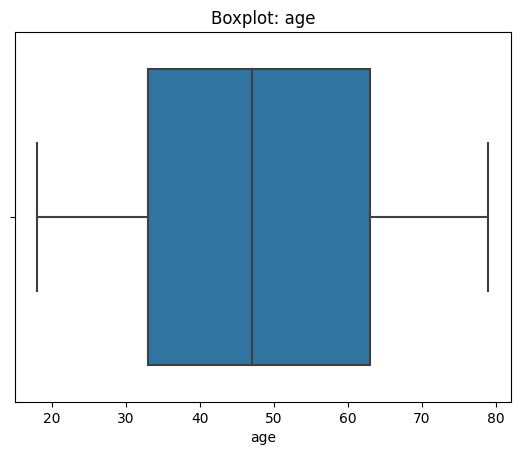

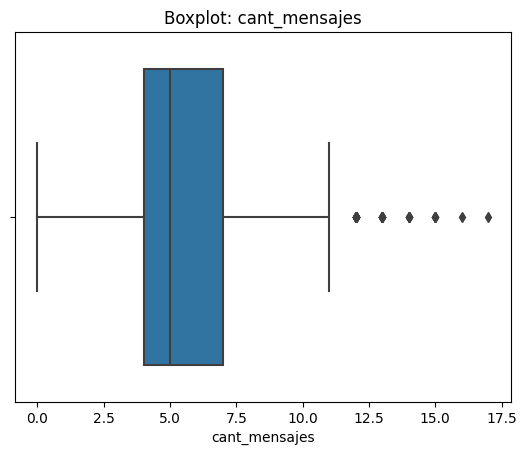

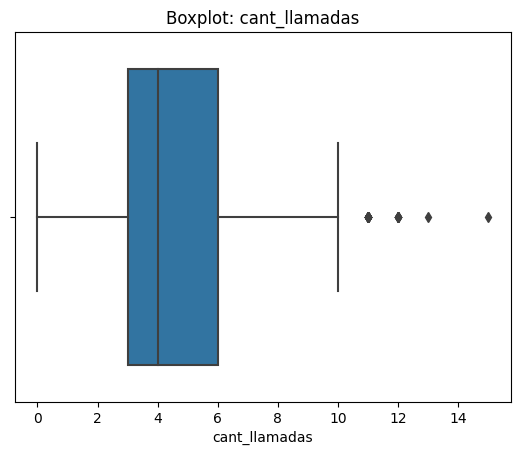

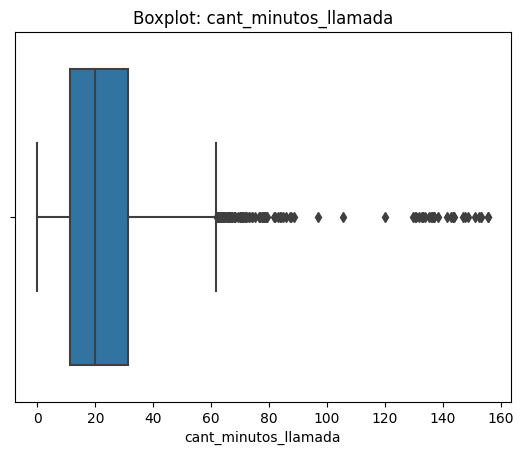

In [56]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
    

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers es una columna simetrica 
- cant_mensajes: presenta outliers con sesgo a la derecha
- cant_llamadas: presenta outliers con sesgo a la derecha
- cant_minutos_llamada: presenta outliers con sesgo a la derecha

In [67]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + ( 1.5 * IQR)
    print(limite_superior)


    
    



108.0
11.5
10.5
61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
  se mantinen los outliers debido a que no es una edad imposible en algunos de los clientes.
- cant_llamadas: mantener o no outliers, porqué?
  se mantienen los outliers debido a que la cantidad de llamadas que hace un cliente puede ser bastante alta y los numeros que vemos son bastante racionales 
- cant_minutos_llamada: mantener o no outliers, porqué?
  se mantienen outliers la cantidad minutos en llamada no es exagerado puede estar facilmente en la cantidad de minutos que una persona hace llamadas 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [71]:
# Crear columna grupo_uso
def clasificar_usuario(fila):
    if fila['cant_llamadas'] <5 and fila['cant_mensajes'] <5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] <10 and fila['cant_mensajes'] <10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificar_usuario, axis=1)

In [72]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [74]:
# Crear columna grupo_edad
def clasificar_edad(fila):
    if fila['age'] <30:
        return 'Joven'
    elif fila['age'] <60:
        return 'Adulto'
    else:
        return 'Adulto mayor'
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [75]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

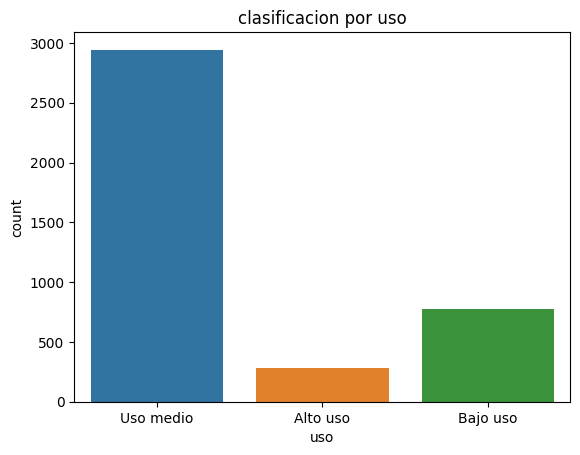

In [78]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('clasificacion por uso')
plt.xlabel('uso')
plt.show()

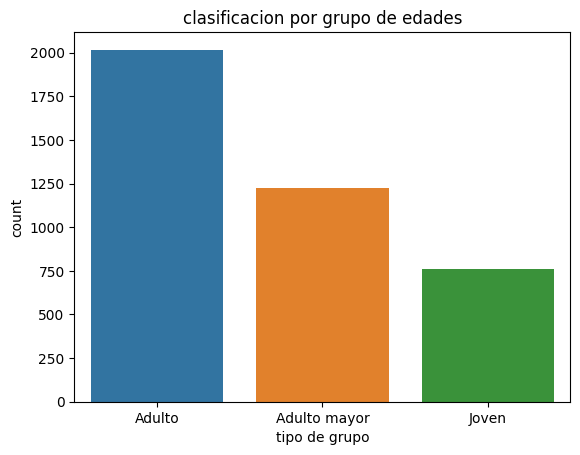

In [81]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('clasificacion por grupo de edades')
plt.xlabel('tipo de grupo')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
encontramos en nuestros data sets sentinels tales como -999 en la columna edades de data Users adicionalmente encontramos otros sentinels como ? para paquetes basicos en el mismo, tambien ciudades vacias para paquetes premium y encontramos un 88% de NA para la columna churn en columnas como duration encontramos un 55% de NA y en length 44%.
en cuanto a la segmentacion por edades identificamos que alrededor de los 50 hay un alza en clientes de paquetes premium y basicos, nuestro histograma nos deja ver que en cuanto a edades tenemos un patron simetrico; desde mi punto de vista concluyo que si segmentamos por duracion, length, plan y edad vemos datos muy valioso ya que nos puede decir como se mueven ambos planes entre edades y cual esta siendo su consumo. los outliers que encontre se ven en calls y text donde se ve que los paquetes basicos usan muchisimo mas que los premium lo que se recomienda es poner topes de consumo en los paquetes basicos junto con un plan de incentivar a estos clientes basicos de alto consumo para que pasen al plan premium donde su consumo puede ser mayor, tambien se podria crear un paquete intermedio que ofrezca paquetes de texto y calls tambien con un tope pero que cada auno de estos topes respete un uso determinado y justo. 

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- churn 88% nulos
- sentinel econtrado -999 en edad
- sentinel en city ? para paquetes basicos
- city tiene filas vacias para paquetes premium en la columna city
- fechas inexistentes en el data users
- duracion 55% NA
- length 44% NA
- duracion y length con outliers



🔍 **Segmentos por Edad**
- la segmentacion determino que tenemos edades simetricas en nuetsro histograma
- la edad que vende mas en ambos paquetes es 50 pero no por un gran rango 


📊 **Segmentos por Nivel de Uso**
- basico tiene un consumo muy superior en cuanto a premium 
- tenemos clientes que usan muchismo mas nuestros servicios lo cual nos genera outliers


➡️ Esto sugiere que no hay un limite en cuuanto al uso de mensajes o llamadas lo cual permite que ambos planes usen estos servicios sin limite 


💡 **Recomendaciones**
- implementar topes de consumo en los paquetes basicos junto con un plan de incentivar a estos clientes basicos de alto consumo para que pasen al plan premium donde su consumo puede ser mayor
-  tambien se podria crear un paquete intermedio que ofrezca paquetes de texto y calls tambien con un tope pero que cada auno de estos topes respete un uso determinado y justo con respecto a los demas paquetes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`